# Understanding the 4-Plot

The **4-Plot** is a single diagnostic panel that simultaneously tests **all four underlying EDA assumptions** for a univariate dataset. It combines four plots in a 2×2 grid, each testing one assumption:

| Panel | Plot | Assumption tested |
|---|---|---|
| Upper-left | Run sequence plot | Fixed location + fixed variation |
| Upper-right | Lag plot | Randomness (independence) |
| Lower-left | Histogram | Fixed distribution (shape) |
| Lower-right | Normal probability plot | Fixed distribution (normality) |

If all four panels look "good", the data satisfies EDA assumptions and standard statistical techniques apply directly.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import SVG, display
import warnings
warnings.filterwarnings('ignore')

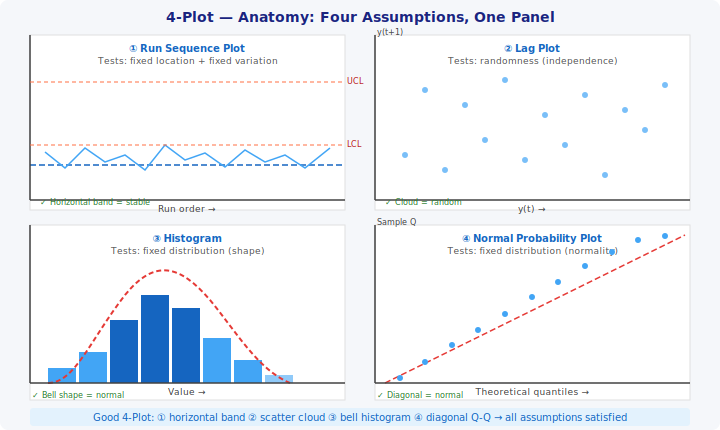

In [2]:
_svg = """
<svg xmlns="http://www.w3.org/2000/svg" width="720" height="430"
     font-family="'Segoe UI', Arial, sans-serif">
  <rect width="720" height="430" fill="#F5F7FA" rx="8"/>
  <text x="360" y="22" text-anchor="middle" font-size="14" font-weight="bold"
        fill="#1A237E">4-Plot — Anatomy: Four Assumptions, One Panel</text>

  <!-- ── UL: Run Sequence ── -->
  <rect x="30" y="35" width="315" height="175" fill="white" stroke="#E0E0E0"/>
  <text x="187" y="52" text-anchor="middle" font-size="10" font-weight="bold" fill="#1565C0">① Run Sequence Plot</text>
  <text x="187" y="64" text-anchor="middle" font-size="9" fill="#555">Tests: fixed location + fixed variation</text>
  <line x1="30" y1="165" x2="345" y2="165" stroke="#1565C0" stroke-width="1.5" stroke-dasharray="6,3"/>
  <polyline points="45,152 65,168 85,148 105,162 125,155 145,170 165,145 185,160
                    205,153 225,167 245,150 265,162 285,155 305,168 330,148"
            fill="none" stroke="#42A5F5" stroke-width="1.5"/>
  <line x1="30" y1="200" x2="345" y2="200" stroke="#424242" stroke-width="1.5"/>
  <line x1="30" y1="200" x2="30"  y2="35"  stroke="#424242" stroke-width="1.5"/>
  <text x="187" y="212" text-anchor="middle" font-size="9" fill="#424242">Run order →</text>
  <text x="40" y="205" font-size="8" fill="#2E7D32">✓ Horizontal band = stable</text>

  <!-- UCL/LCL -->
  <line x1="30" y1="82" x2="345" y2="82" stroke="#FF7043" stroke-width="1" stroke-dasharray="4,3"/>
  <line x1="30" y1="145" x2="345" y2="145" stroke="#FF7043" stroke-width="1" stroke-dasharray="4,3"/>
  <text x="347" y="84" font-size="8" fill="#B71C1C">UCL</text>
  <text x="347" y="147" font-size="8" fill="#B71C1C">LCL</text>

  <!-- ── UR: Lag Plot ── -->
  <rect x="375" y="35" width="315" height="175" fill="white" stroke="#E0E0E0"/>
  <text x="532" y="52" text-anchor="middle" font-size="10" font-weight="bold" fill="#1565C0">② Lag Plot</text>
  <text x="532" y="64" text-anchor="middle" font-size="9" fill="#555">Tests: randomness (independence)</text>
  <!-- random scatter cloud -->
  <circle cx="405" cy="155" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="425" cy="90"  r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="445" cy="170" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="465" cy="105" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="485" cy="140" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="505" cy="80"  r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="525" cy="160" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="545" cy="115" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="565" cy="145" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="585" cy="95"  r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="605" cy="175" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="625" cy="110" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="645" cy="130" r="3" fill="#42A5F5" opacity="0.7"/>
  <circle cx="665" cy="85"  r="3" fill="#42A5F5" opacity="0.7"/>
  <line x1="375" y1="200" x2="690" y2="200" stroke="#424242" stroke-width="1.5"/>
  <line x1="375" y1="200" x2="375" y2="35"  stroke="#424242" stroke-width="1.5"/>
  <text x="532" y="212" text-anchor="middle" font-size="9" fill="#424242">y(t) →</text>
  <text x="377" y="35" font-size="8" fill="#424242">y(t+1)</text>
  <text x="385" y="205" font-size="8" fill="#2E7D32">✓ Cloud = random</text>

  <!-- ── LL: Histogram ── -->
  <rect x="30" y="225" width="315" height="175" fill="white" stroke="#E0E0E0"/>
  <text x="187" y="242" text-anchor="middle" font-size="10" font-weight="bold" fill="#1565C0">③ Histogram</text>
  <text x="187" y="254" text-anchor="middle" font-size="9" fill="#555">Tests: fixed distribution (shape)</text>
  <!-- normal-looking bars -->
  <rect x="48"  y="368" width="28" height="15"  fill="#42A5F5"/>
  <rect x="79"  y="352" width="28" height="31"  fill="#42A5F5"/>
  <rect x="110" y="320" width="28" height="63"  fill="#1565C0"/>
  <rect x="141" y="295" width="28" height="88"  fill="#1565C0"/>
  <rect x="172" y="308" width="28" height="75"  fill="#1565C0"/>
  <rect x="203" y="338" width="28" height="45"  fill="#42A5F5"/>
  <rect x="234" y="360" width="28" height="23"  fill="#42A5F5"/>
  <rect x="265" y="375" width="28" height="8"   fill="#90CAF9"/>
  <!-- normal curve overlay -->
  <path d="M 48,383 C 75,383 90,340 125,295 C 155,258 180,265 210,300 C 235,330 258,370 290,383"
        fill="none" stroke="#E53935" stroke-width="2" stroke-dasharray="5,3"/>
  <line x1="30" y1="383" x2="345" y2="383" stroke="#424242" stroke-width="1.5"/>
  <line x1="30" y1="383" x2="30"  y2="225" stroke="#424242" stroke-width="1.5"/>
  <text x="187" y="395" text-anchor="middle" font-size="9" fill="#424242">Value →</text>
  <text x="32" y="398" font-size="8" fill="#2E7D32">✓ Bell shape = normal</text>

  <!-- ── LR: Normal Probability Plot ── -->
  <rect x="375" y="225" width="315" height="175" fill="white" stroke="#E0E0E0"/>
  <text x="532" y="242" text-anchor="middle" font-size="10" font-weight="bold" fill="#1565C0">④ Normal Probability Plot</text>
  <text x="532" y="254" text-anchor="middle" font-size="9" fill="#555">Tests: fixed distribution (normality)</text>
  <!-- points on diagonal -->
  <line x1="385" y1="383" x2="685" y2="235" stroke="#E53935" stroke-width="1.5" stroke-dasharray="6,3"/>
  <circle cx="400" cy="378" r="3" fill="#42A5F5"/>
  <circle cx="425" cy="362" r="3" fill="#42A5F5"/>
  <circle cx="452" cy="345" r="3" fill="#42A5F5"/>
  <circle cx="478" cy="330" r="3" fill="#42A5F5"/>
  <circle cx="505" cy="314" r="3" fill="#42A5F5"/>
  <circle cx="532" cy="297" r="3" fill="#42A5F5"/>
  <circle cx="558" cy="282" r="3" fill="#42A5F5"/>
  <circle cx="585" cy="266" r="3" fill="#42A5F5"/>
  <circle cx="612" cy="252" r="3" fill="#42A5F5"/>
  <circle cx="638" cy="240" r="3" fill="#42A5F5"/>
  <circle cx="665" cy="236" r="3" fill="#42A5F5"/>
  <line x1="375" y1="383" x2="690" y2="383" stroke="#424242" stroke-width="1.5"/>
  <line x1="375" y1="383" x2="375" y2="225" stroke="#424242" stroke-width="1.5"/>
  <text x="532" y="395" text-anchor="middle" font-size="9" fill="#424242">Theoretical quantiles →</text>
  <text x="377" y="225" font-size="8" fill="#424242">Sample Q</text>
  <text x="377" y="398" font-size="8" fill="#2E7D32">✓ Diagonal = normal</text>

  <!-- Takeaway -->
  <rect x="30" y="408" width="660" height="18" fill="#E3F2FD" rx="3"/>
  <text x="360" y="421" text-anchor="middle" font-size="10" fill="#1565C0">
    Good 4-Plot: ① horizontal band  ② scatter cloud  ③ bell histogram  ④ diagonal Q-Q → all assumptions satisfied
  </text>
</svg>
"""
display(SVG(_svg))

## Interpreting a 4-Plot

| Panel | Good (assumptions satisfied) | Bad (assumption violated) |
|---|---|---|
| **① Run Sequence** | Points in a horizontal band | Trend up/down (non-fixed location) or widening spread (non-fixed variation) |
| **② Lag Plot** | Random scatter cloud | Diagonal line → positive autocorr; anti-diagonal → negative; ellipse → periodic |
| **③ Histogram** | Bell-shaped, symmetric | Skewed, bimodal, flat |
| **④ Normal Probability Plot** | Points lie on diagonal | S-curve → heavy tails; banana → skewness; steps → discretised data |

**What to do when the 4-Plot shows a violation:**

| Violation | Remediation |
|---|---|
| Trend in run sequence | Detrend; include time as a covariate |
| Autocorrelation (lag plot) | Use time-series models (ARIMA); don't treat as IID |
| Non-normal histogram | Apply Box-Cox / log transform; use non-parametric tests |
| Non-normal Q-Q plot | Same as above; or use robust estimators |

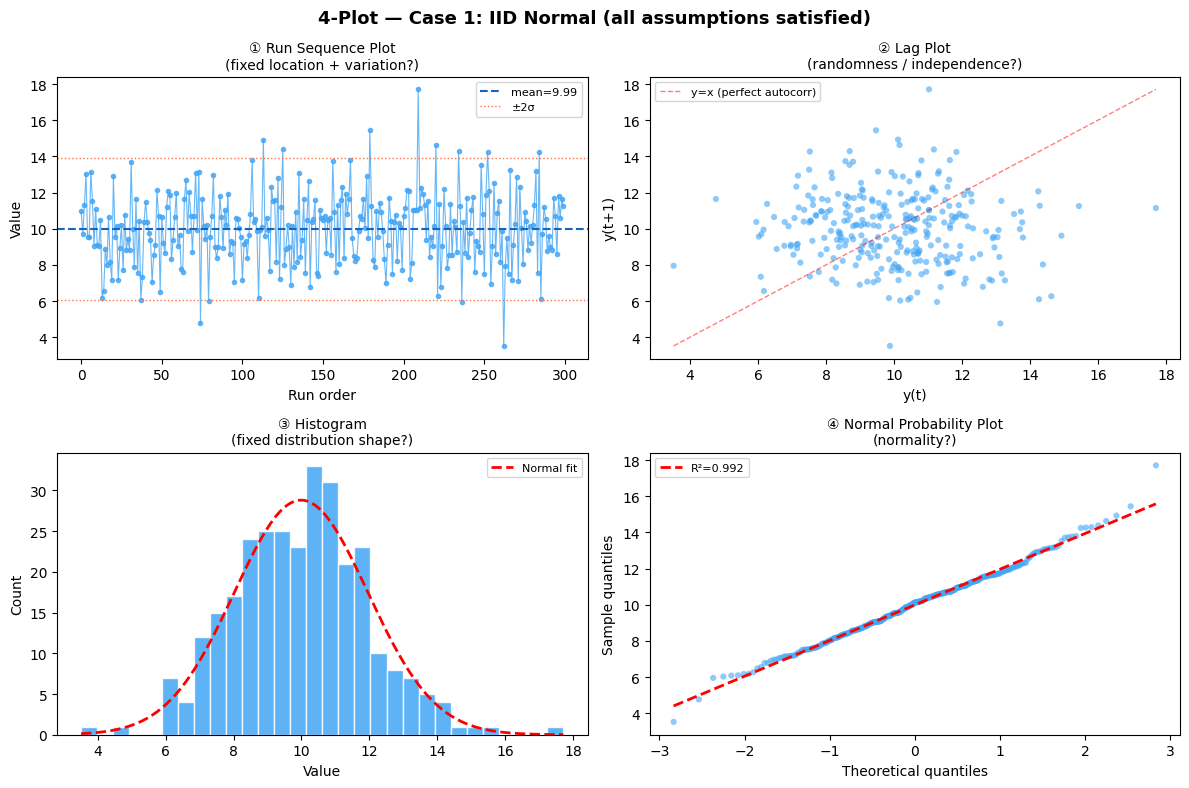

In [3]:
def four_plot(y, title="4-Plot"):
    """4-Plot: run sequence, lag, histogram, normal Q-Q."""
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    n = len(y)
    idx = np.arange(n)

    # ① Run Sequence Plot
    ax = axes[0, 0]
    ax.plot(idx, y, 'o-', color='#42A5F5', markersize=3, linewidth=0.8, alpha=0.8)
    mu, sigma = np.mean(y), np.std(y)
    ax.axhline(mu, color='#1565C0', linewidth=1.5, linestyle='--', label=f'mean={mu:.2f}')
    ax.axhline(mu + 2*sigma, color='#FF7043', linewidth=1, linestyle=':', label='±2σ')
    ax.axhline(mu - 2*sigma, color='#FF7043', linewidth=1, linestyle=':')
    ax.set_title('① Run Sequence Plot\n(fixed location + variation?)', fontsize=10)
    ax.set_xlabel('Run order')
    ax.set_ylabel('Value')
    ax.legend(fontsize=8)

    # ② Lag Plot
    ax = axes[0, 1]
    ax.scatter(y[:-1], y[1:], color='#42A5F5', alpha=0.6, s=20, edgecolors='none')
    lo, hi = y.min(), y.max()
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1, alpha=0.5, label='y=x (perfect autocorr)')
    ax.set_title('② Lag Plot\n(randomness / independence?)', fontsize=10)
    ax.set_xlabel('y(t)')
    ax.set_ylabel('y(t+1)')
    ax.legend(fontsize=8)

    # ③ Histogram
    ax = axes[1, 0]
    ax.hist(y, bins=min(30, n//10 + 5), color='#42A5F5', edgecolor='white', alpha=0.85)
    # normal overlay
    x_range = np.linspace(y.min(), y.max(), 200)
    pdf = stats.norm.pdf(x_range, mu, sigma) * n * (y.max()-y.min()) / (min(30, n//10+5))
    ax.plot(x_range, pdf, 'r--', linewidth=2, label='Normal fit')
    ax.set_title('③ Histogram\n(fixed distribution shape?)', fontsize=10)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

    # ④ Normal Probability Plot
    ax = axes[1, 1]
    (osm, osr), (slope, intercept, r) = stats.probplot(y, dist='norm')
    ax.scatter(osm, osr, color='#42A5F5', alpha=0.6, s=20, edgecolors='none')
    ax.plot(osm, slope*np.array(osm) + intercept, 'r--', linewidth=2,
            label=f'R²={r**2:.3f}')
    ax.set_title('④ Normal Probability Plot\n(normality?)', fontsize=10)
    ax.set_xlabel('Theoretical quantiles')
    ax.set_ylabel('Sample quantiles')
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

np.random.seed(42)

# ── Case 1: All assumptions satisfied (IID Normal) ──
y_good = np.random.normal(10, 2, 300)
four_plot(y_good, "4-Plot — Case 1: IID Normal (all assumptions satisfied)")

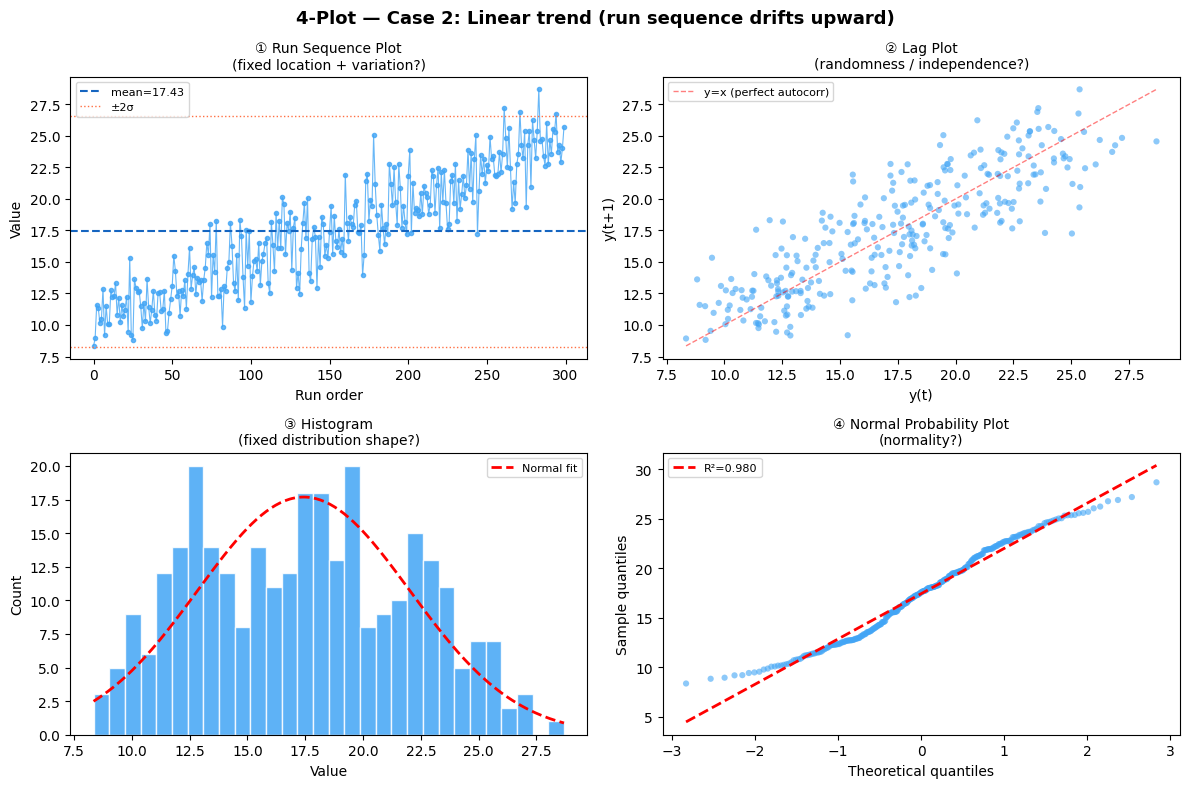

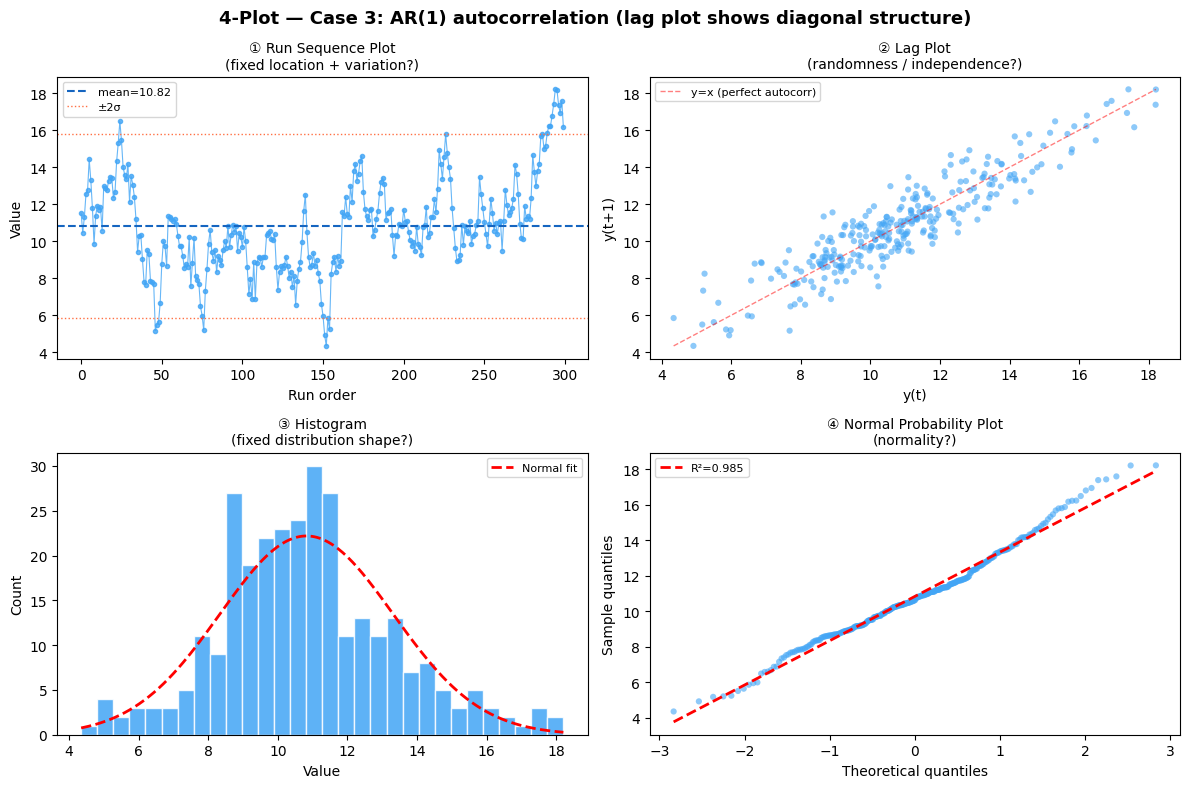

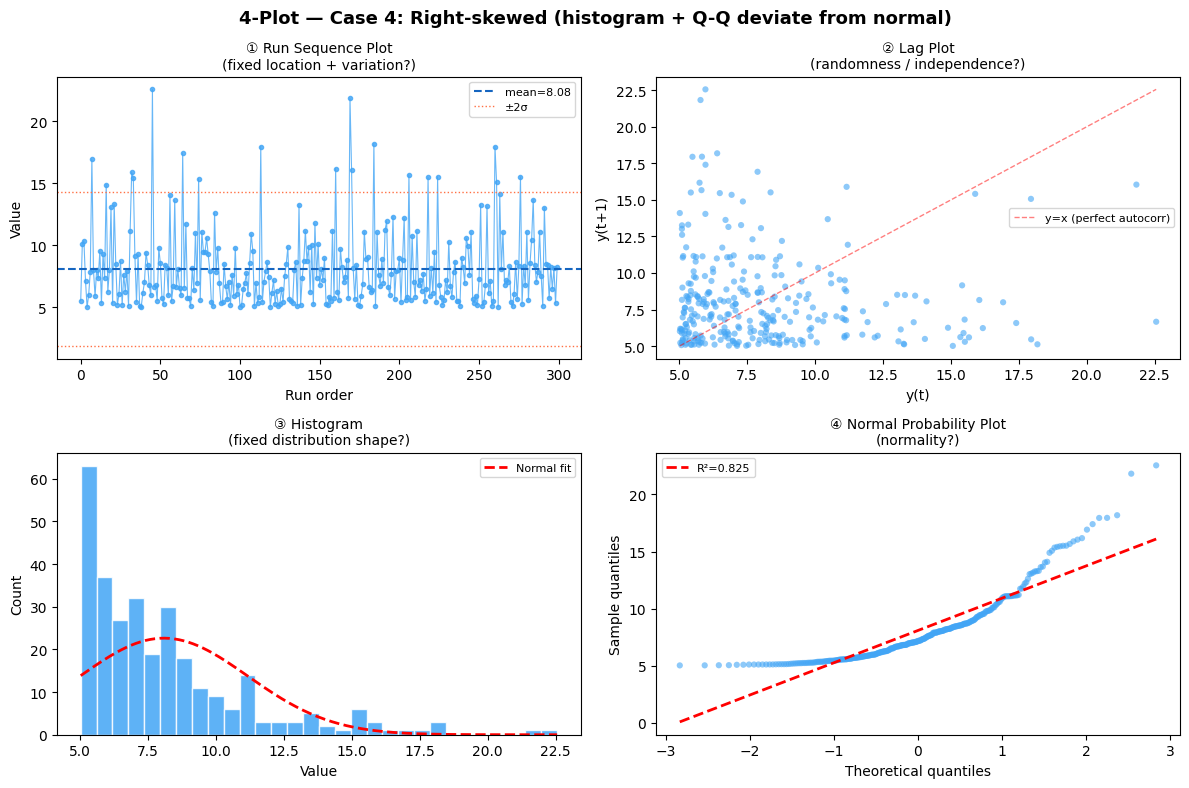

In [4]:
# ── Case 2: Linear trend (non-fixed location) ──
t = np.arange(300)
y_trend = 10 + 0.05*t + np.random.normal(0, 2, 300)
four_plot(y_trend, "4-Plot — Case 2: Linear trend (run sequence drifts upward)")

# ── Case 3: Autocorrelated AR(1) process ──
alpha = 0.92
y_ar = np.zeros(300)
y_ar[0] = np.random.normal(10, 2)
for i in range(1, 300):
    y_ar[i] = 10 + alpha*(y_ar[i-1] - 10) + np.random.normal(0, 1)
four_plot(y_ar, "4-Plot — Case 3: AR(1) autocorrelation (lag plot shows diagonal structure)")

# ── Case 4: Right-skewed (exponential) ──
y_skew = np.random.exponential(scale=3, size=300) + 5
four_plot(y_skew, "4-Plot — Case 4: Right-skewed (histogram + Q-Q deviate from normal)")

## Key Takeaways

| | |
|---|---|
| **Purpose** | Single panel that tests all 4 EDA assumptions simultaneously |
| **Assumption 1** | Fixed location — run sequence horizontal band |
| **Assumption 2** | Fixed variation — constant spread in run sequence |
| **Assumption 3** | Randomness — lag plot scatter cloud |
| **Assumption 4** | Fixed distribution (normality) — bell histogram + diagonal Q-Q |
| **Standard use** | Apply 4-Plot before any parametric test (t-test, ANOVA, regression) |
| **If all panels pass** | Standard statistical summaries (mean, σ) and tests are valid |
| **If any panel fails** | Identify which assumption fails → apply appropriate transform or model |
| **vs individual plots** | 4-Plot is more efficient; individual plots allow more zooming in on violations |